<a href="https://colab.research.google.com/github/vdlucas-queiroz/CadImobi/blob/main/COTIA_prompt_az_dist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# RECONSTRUÇÃO DE GEOMETRIA DE MEMORIAL DESCRITIVO POR MEIO DE AZIMUTES E DISTÂNCIAS
# CRIAR UM EXECUTÁVEL DESSA APLICAÇÃO:
'''
1. Recebe a tabela de az-dist e tem um campo para colocar a coordenada do primeiro ponto;
2. Retorna ao usuário a tabela de coordenadas no formato da geopixel (ou só organiza a tabela na forma e grau decimal e distância);

ob.. a parte de IA fica fora pra não dar problemas nem gerar dependencia de código!
'''

# Vinicius D'Lucas Bezerra e Queiroz

'\n1. Recebe a tabela de az-dist e tem um campo para colocar a coordenada do primeiro ponto;\n2. Retorna ao usuário a tabela de coordenadas no formato da geopixel (ou só organiza a tabela na forma e grau decimal e distância);\n\nob.. a parte de IA fica fora pra não dar problemas nem gerar dependencia de código!\n'

In [ ]:
!pip install adjustText
!pip install simplekml
!pip install folium pyproj
!pip cache purge
!pip install -U google-genai


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65939 sha256=cb20e809ec9fd7b010315e7893492bba257453a779194ebbc5bba7194eaa9d4d
  Stored in directory: /root/.cache/pip/wheels/fd/2a/d1/84a7abdbb59566c442beb1b4fb946fe1e26c5a48fd1d5e0763
Successfully built simplekml
Files removed: 11
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.5/263.5 kB 13.7 MB/s eta 0:00:00
  Attempting uninstall: google-auth
    Found existing installation: google-auth 2.49.0
    Uninstalling google-auth-2.49.0:
      Successfully uninstalled google-auth-2.49.0
  Attempting uninstall: google-genai
    Found existing installation: google-genai 2.12.1
    Uninstalling google-genai-2.12.1:
      Successfully uninstall

In [ ]:
import pandas as pd
import numpy as np
from shapely.geometry import Polygon
import matplotlib.pyplot as plt
from adjustText import adjust_text
import folium
from pyproj import Transformer

from google.colab import files
from google import genai
from google.colab import userdata
import re
import time
import json


In [ ]:
# 1. Configuração da API
try:
    api_key = userdata.get('GEMINI_API_KEY')
    client = genai.Client(api_key=api_key)
    print("API Configurada com sucesso!")
except Exception as e:
    print("ERRO: Configure o Secret 'GEMINI_API_KEY' no menu lateral.")

def obter_tabela_via_ai(caminho_arquivo, prompt):
    """
    Envia o arquivo (PDF ou Imagem) diretamente para o Gemini.
    A IA faz o OCR (leitura de imagem) e a extração dos dados em um único passo.
    """

    # Busca o nome correto do modelo disponível
    nome_modelo = 'gemini-2.5-flash' # Versão estável e rápida

    # 2. Upload do arquivo para a API do Google (suporta PDF e Imagens)
    print(f"Fazendo upload do arquivo: {caminho_arquivo}...")
    sample_file = client.files.upload(file=caminho_arquivo)

    # Aguarda o processamento do arquivo pelo Google
    while sample_file.state.name == "PROCESSING":
        print(".", end="")
        time.sleep(2)
        sample_file = client.files.get(name=sample_file.name)

    # 3. Prompt especializado (ajustado para ler páginas 3 a 7) #AJUSTAR O PROMPT

    print("Gemini analisando o documento (OCR + Extração)...")
    response = client.models.generate_content(
        model=nome_modelo,
        contents=[sample_file, prompt],
        config={
            "response_mime_type": "application/json"
        }
    )

  # 4. Limpeza (opcional, mas boa prática)
    client.files.delete(name=sample_file.name)

    return response.text


API Configurada com sucesso!


In [ ]:
# Funções

# Conversão de gms para decimal

def gms_to_decimal(az_g,az_m,ag_s):
    return az_g + az_m/60 + ag_s/3600


# Teste de rotação de coordenadas

def rotate_coords(coords, theta, pivot):
    coords = np.array(coords, dtype=float)
    x0, y0 = pivot

    translated = coords - np.array([x0, y0])

    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta),  np.cos(theta)]
    ])

    rotated = translated @ R.T
    return rotated + np.array([x0, y0])

  # PLOTAGEM OS RESULTADOS COM MAPA BASE

def plot_vertices_folium(
    coords,
    epsg_utm="EPSG:31983",
    zoom_start=18
):
    """
    Plota vértices e polígono em um mapa Folium.
    """

    from pyproj import Transformer
    import folium

    # Transformador UTM -> WGS84
    transformer = Transformer.from_crs(
        epsg_utm,
        "EPSG:4326",
        always_xy=True
    )

    # Conversão das coordenadas
    coords_geo = [transformer.transform(x, y) for x, y in coords]

    # Centro do mapa
    lon_c = sum(pt[0] for pt in coords_geo) / len(coords_geo)
    lat_c = sum(pt[1] for pt in coords_geo) / len(coords_geo)

    m = folium.Map(
        location=[lat_c, lon_c],
        zoom_start=zoom_start,
        tiles="OpenStreetMap"
    )

    # Polígono (AMARELO)
    folium.Polygon(
        locations=[(lat, lon) for lon, lat in coords_geo],
        color="yellow",
        weight=2,
        fill=True,
        fill_color="yellow",
        fill_opacity=0.3,
        tooltip="Polígono reconstruído"
    ).add_to(m)

    # Vértices (PONTOS BRANCOS)
    for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
        nome = f"P{i+1:02d}"

        # Destaque do ponto inicial
        radius = 7 if i == 0 else 5

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color="white",
            fill=True,
            fill_color="white",
            fill_opacity=1,
            popup=(
                f"<b>{nome}</b><br>"
                f"UTM 23S (SIRGAS2000)<br>"
                f"X = {x:.3f} m<br>"
                f"Y = {y:.3f} m"
            )
        ).add_to(m)

        # Rótulo fixo (FONTE BRANCA)
        folium.Marker(
            location=[lat, lon],
            icon=folium.DivIcon(
                html=f"""
                <div style="
                    font-size:10px;
                    font-weight:bold;
                    color:white;
                    text-shadow: 1px 1px 2px black;
                    transform: translate(6px, -6px);
                ">
                    {nome}
                </div>
                """
            )
        ).add_to(m)

    # Camada de imagem de satélite
    folium.TileLayer(
        "Esri.WorldImagery",
        name="Imagem de Satélite (ESRI)",
        control=True
    ).add_to(m)

    folium.LayerControl().add_to(m)

    return m




1. EXTRAÇÃO DE AZIMUTE E DISTÂNCIA EM TEXTO

In [ ]:
prompt = """
Você é um especialista em georreferenciamento de imoveis e topografia.
Analise as PÁGINAS 3 A 7 deste documento.

Extraia todos os alinhamentos (De-Para, Azimute e Distância) do memorial descritivo.
Mesmo que o documento seja uma imagem digitalizada, faça o OCR e extraia os dados.

Formate o resultado EXATAMENTE como uma lista de tuplas em Python:
data = [
    ("01-02", "220°19'20\\"", 27.39),
    ("02-03", "227°58'29\\"", 8.00),
]

Regras:
1. Retorne APENAS o código da lista, nada de explicações ou Markdown.
2. O azimute deve ser string com símbolos de graus, minutos e segundos.
3. A distância deve ser float (use ponto para decimais).
4. Não pule nenhum vértice. Verifique do ponto 01 até o fechamento.
"""


In [ ]:
prompt = """
Você é um especialista em georreferenciamento de imoveis e topografia.
Analise as páginas 3 a 6 deste documento.

Extraia todos os alinhamentos (De-Para, Azimute e Distância) do memorial descritivo.
Mesmo que o documento seja uma imagem digitalizada, faça o OCR e extraia os dados.
Utilize o nome dos pontos como estão no documento. Separe o ângulo em grau minuto e segundo (3 colunas)

[
  {"alinhamento": "01-02", "azimute_g": 200, "azimute_m": 10, "azimute_s": 55, "distancia": 27.39},
  {"alinhamento": "02-03", "azimute_g": 210, "azimute_m": 44, "azimute_s": 12, "distancia": 8.00}
]


Regras:
1. Retorne APENAS o código da lista, nada de explicações ou Markdown.
2. O azimute deve ser string com símbolos de graus, minutos e segundos.
3. A distância deve ser float (use ponto para decimais).
4. Não pule nenhum vértice. Verifique do ponto 01 até o fechamento.
"""

In [ ]:
# --- EXECUÇÃO --- PROMPT 1
#arquivo = "/content/matricula.pdf" # Pode ser .pdf, .png, .jpg ou .jpeg
arquivo = "/content/mat.pdf"

try:
    resultado_bruto = obter_tabela_via_ai(arquivo, prompt)

    # Limpeza de Markdown
    codigo_limpo = re.sub(r'```json|```python|```', '', resultado_bruto).strip()

    # Executa o código para gerar a variável 'data'
    data = json.loads(codigo_limpo)

    print("\n--- SUCESSO ---")
    print(f"Total de alinhamentos: {len(data)}")
    print("Exemplo dos primeiros dados:", data[:5])

except Exception as e:
    print(f"\nErro no processamento: {e}")

Fazendo upload do arquivo: /content/mat.pdf...
Gemini analisando o documento (OCR + Extração)...



--- SUCESSO ---
Total de alinhamentos: 77
Exemplo dos primeiros dados: [{'alinhamento': 'DLH-M-0175-DLH-P-0265', 'azimute_g': 110, 'azimute_m': 51, 'azimute_s': 0, 'distancia': 45.83}, {'alinhamento': 'DLH-P-0265-DLH-P-0266', 'azimute_g': 112, 'azimute_m': 25, 'azimute_s': 0, 'distancia': 27.54}, {'alinhamento': 'DLH-P-0266-DLH-P-0267', 'azimute_g': 114, 'azimute_m': 10, 'azimute_s': 0, 'distancia': 26.19}, {'alinhamento': 'DLH-P-0267-DLH-P-0268', 'azimute_g': 109, 'azimute_m': 1, 'azimute_s': 0, 'distancia': 14.18}, {'alinhamento': 'DLH-P-0268-DLH-P-0269', 'azimute_g': 95, 'azimute_m': 1, 'azimute_s': 0, 'distancia': 51.64}]


In [ ]:
#csv na mão
data = [
  {"alinhamento": "P3-P4", "azimute_g": 327, "azimute_m": 35, "azimute_s": 39, "distancia":4.79},
  {"alinhamento": "P4-P5", "azimute_g": 315, "azimute_m": 17, "azimute_s": 58, "distancia": 10.21},
  {"alinhamento": "P5-P6", "azimute_g": 3, "azimute_m": 24, "azimute_s": 3, "distancia": 46.14},
  {"alinhamento": "P6-P7", "azimute_g": 352, "azimute_m": 45, "azimute_s": 7, "distancia":22.18},
  {"alinhamento": "P7-P7A", "azimute_g": 68, "azimute_m": 22, "azimute_s": 27, "distancia": 27.79},
  {"alinhamento": "P7A-P3A", "azimute_g": 148, "azimute_m": 20, "azimute_s": 29, "distancia": 55.82},
{"alinhamento": "P3A-P3", "azimute_g": 227, "azimute_m": 7, "azimute_s": 6, "distancia": 61.85}
  ]




In [ ]:
# Gerando dataframe
df = pd.DataFrame(data, columns=["alinhamento","azimute_g","azimute_m","azimute_s","distancia"])
df


,alinhamento,azimute_g,azimute_m,azimute_s,distancia
0,DLH-M-0175-DLH-P-0265,110,51,0,45.83
1,DLH-P-0265-DLH-P-0266,112,25,0,27.54
2,DLH-P-0266-DLH-P-0267,114,10,0,26.19
3,DLH-P-0267-DLH-P-0268,109,1,0,14.18
4,DLH-P-0268-DLH-P-0269,95,1,0,51.64
...,...,...,...,...,...
72,DLH-M-0181-DLH-P-0337,52,22,0,28.41
73,DLH-P-0337-DLH-P-0338,52,46,0,108.36
74,DLH-P-0338-DLH-P-0339,46,18,0,33.45
75,DLH-P-0339-DLH-P-0340,41,13,0,37.57


In [ ]:
# Caso necessite remover vários índices de uma vez
indices_to_remove = sorted(list(range(0, 1)) + [7,8 ,9], reverse=True)
data_cp = data.copy()
for index in indices_to_remove:
    if index < len(data):  # Ensure index is within bounds
        del data_cp[index]

# Display the updated data
pd.DataFrame(data_cp)

,alinhamento,azimute_g,azimute_m,azimute_s,distancia
0,02-02A,0,0,0,3.87
1,02A-02B,245,17,42,5.13
2,02B-02C,335,17,42,10.05
3,02C-02D,245,17,13,139.02
4,02D-02E,340,33,35,18.35
5,02E-22A,349,48,29,90.24


In [ ]:
df = pd.DataFrame(data_cp, columns=["alinhamento","azimute_g","azimute_m","azimute_s","distancia"])

NameError: name 'data_cp' is not defined

In [ ]:
# Correção de pontos
df.at[10, 'azimute'] = '164°27\'08'
df.at[24, 'azimute'] = '261°48\'01'
df.at[24, 'distancia'] = 11.71
df.at[30, 'azimute'] = '5°38\'53'

In [ ]:
df.at[12, 'distancia'] = 00.26
df.at[15, 'azimute_m'] = 25

In [ ]:
# Exportação da tabela de pontos corrigida
file_name = "memorial_25.csv"
df.to_csv(file_name, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

2. CÁLCULO PARA GERAÇÃO DE MEMORIAL DESCRITIVO

In [ ]:
# CASO JÁ TENHA GERADO O RESULTADO ANTERIORMENTE, IMPORTE O CSV AQUI

df = pd.read_csv('/content/memorial_75.csv')
df

In [ ]:
df["Az_deg"] = gms_to_decimal(df["azimute_g"],df["azimute_m"],df["azimute_s"])
df["Az_rad"] = np.deg2rad(df["Az_deg"])

# -----------------------------
# 3. Cálculo incremental
# -----------------------------
df["dX"] = df["distancia"] * np.sin(df["Az_rad"])
df["dY"] = df["distancia"] * np.cos(df["Az_rad"])

# -----------------------------
# 4. Propagação das coordenadas
# -----------------------------
X0, Y0 = 302792.310, 7376309.322

coords = [(X0, Y0)]
x, y = X0, Y0

for dx, dy in zip(df["dX"], df["dY"]):
    x += dx
    y += dy
    coords.append((x, y))

# -----------------------------
# 5. Construção do polígono
# -----------------------------
polygon = Polygon(coords)

# -----------------------------
# 6. Tabela final de vértices
# -----------------------------
vertices = pd.DataFrame(coords, columns=["X","Y"],)
vertices["Vertice"] = [f"P{i+1:02d}" for i in range(len(vertices))]
xv, yv = zip(*coords)

print(vertices)

                X             Y Vertice
0   302792.310000  7.376309e+06     P01
1   302835.138842  7.376293e+06     P02
2   302860.597786  7.376283e+06     P03
3   302884.492454  7.376272e+06     P04
4   302897.898564  7.376267e+06     P05
..            ...           ...     ...
73  302638.736969  7.376171e+06     P74
74  302725.010821  7.376236e+06     P75
75  302749.194072  7.376259e+06     P76
76  302773.949257  7.376288e+06     P77
77  302792.344544  7.376309e+06     P78

[78 rows x 3 columns]


In [ ]:
# Exportando txt estilo geopixel
file_name = "mat.txt"
vertices[['X', 'Y']].to_csv(file_name, sep=' ', header=False, index=False)
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import math

In [ ]:
# SE NECESSÁRIO ROTACIONAR
theta = -4.71239  # rad
print(theta)
# Polígono original
polygon = Polygon(coords)

# Pivô recomendado: centroide
pivot = coords[0]

# Rotação
coords_rot_array = rotate_coords(coords, theta, pivot)

# 🔹 AJUSTE FUNDAMENTAL:
# mesmo formato de coords → lista de tuplas
coords_rot = [(x, y) for x, y in coords_rot_array]


-4.71239


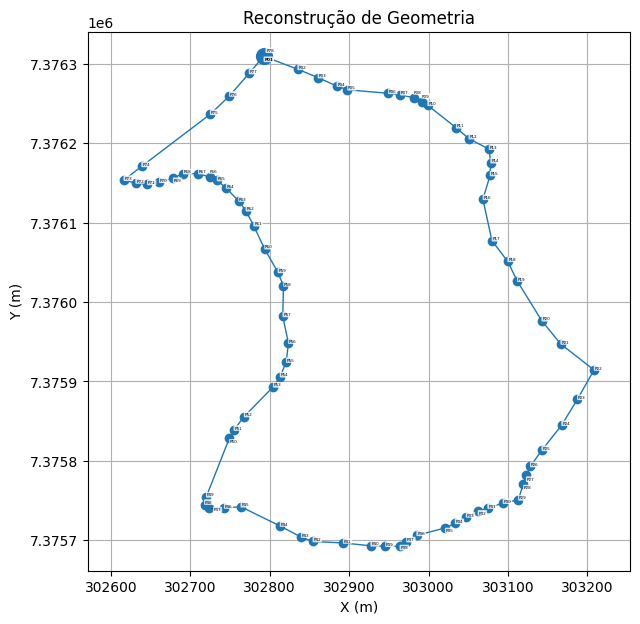

In [ ]:
# PLOTAGEM OS RESULTADOS SEM MAPA BASE

plt.figure(figsize=(7,7))
plt.plot(xv, yv, marker="o", linewidth=1)

texts = []

for i, (x, y) in enumerate(coords):
    label = f"P{i+1:02d}"

    if i == 0:
        plt.scatter(x, y, s=130, zorder=5)
        weight = "bold"
    else:
        weight = "normal"

    txt = plt.text(
        x, y, label,
        fontsize=3,
        fontweight=weight,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.8),
        zorder=6
    )
    texts.append(txt)

# Ajuste automático (repulsão)
adjust_text(
    texts,
    x=xv,
    y=yv,
    expand_points=(1.5, 1.5),
    expand_text=(1.4, 1.4),
    force_points=0.4,
    force_text=0.8,
    arrowprops=dict(arrowstyle="-", lw=0.5)
)

plt.axis("equal")
plt.grid(True)
plt.title("Reconstrução de Geometria")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.savefig('reconstrucao_geometria.png', bbox_inches='tight')
plt.show()


In [ ]:
from google.colab import files

# Certifique-se de que o plot foi salvo primeiro na célula anterior (F9d41GmJFvEc).
# Adicione plt.savefig('reconstrucao_geometria.png', bbox_inches='tight') antes de plt.show() nela.
file_name = 'reconstrucao_geometria.png'
files.download(file_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# CÁLCULO DE ÁREA PELO MÉTODO ANALÍTICO DE GAUSS
coords_array = np.array(coords)
coords_array = coords_array[:-1]

x = coords_array[:, 0]
y = coords_array[:, 1]

area_m2 = 0.5 * abs(
    np.dot(x, np.roll(y, -1)) - np.dot(y, np.roll(x, -1))
)

area_ha = area_m2 / 10_000

print(f"Área (Shoelace): {area_m2:,.2f} m² ({area_ha:.4f} ha)")


Área (Shoelace): 230,139.71 m² (23.0140 ha)


In [ ]:
# PLOTAGEM COM MAPA BASE
m = plot_vertices_folium(coords[:-1])
m

In [ ]:
import geopandas as gpd
from shapely.geometry import Polygon

# Exclude the last point from coords for the polygon (as it's often a duplicate of the first for closure)
# Create a GeoDataFrame from the polygon using the unique vertices
gdf_polygon = gpd.GeoDataFrame(index=[0], crs="EPSG:31983", geometry=[Polygon(coords[:-1])])

# Define the output GPKG file name
output_gpkg_file = "polygon2.gpkg"

# Export to GPKG format
gdf_polygon.to_file(output_gpkg_file, driver='GPKG')

print(f"Polígono exportado com sucesso para '{output_gpkg_file}'")

Polígono exportado com sucesso para 'polygon2.gpkg'


In [ ]:
import simplekml
from pyproj import Transformer

# EXPORTAÇÃO DA GEOMETRIA

# Transformação: SIRGAS2000 / UTM 23S -> WGS84
transformer = Transformer.from_crs(
    "EPSG:31983",  # SIRGAS2000 / UTM 23S
    "EPSG:4326",   # WGS84 (obrigatório para KML)
    always_xy=True
)

coords_geo = [transformer.transform(x, y) for x, y in coords]

kml = simplekml.Kml()

# Documento com descrição técnica
kml.document.name = "Vértices – Memorial Descritivo"
kml.document.description = (
    "Geometria originalmente calculada em:\n"
    "SIRGAS 2000 / UTM Zona 23S (EPSG:31983)\n\n"
    "Conversão para WGS84 (EPSG:4326) realizada "
    "exclusivamente para compatibilidade com o formato KML."
)

for i, ((x, y), (lon, lat)) in enumerate(zip(coords, coords_geo)):
    nome = f"P{i+1:02d}"

    pnt = kml.newpoint(
        name=nome,
        coords=[(lon, lat)]
    )

    pnt.description = (
        f"Vértice {nome}\n\n"
        f"SIRGAS2000 / UTM 23S:\n"
        f"X = {x:.3f} m\n"
        f"Y = {y:.3f} m\n\n"
        f"WGS84 (KML):\n"
        f"Lon = {lon:.8f}\n"
        f"Lat = {lat:.8f}"
    )

    pnt.style.iconstyle.scale = 0.9
    pnt.style.iconstyle.icon.href = (
        "http://maps.google.com/mapfiles/kml/shapes/placemark_circle.png"
    )

output_kml = "/content/vertices_sirgas2000_utm23S.kml"
kml.save(output_kml)

output_kml


'/content/vertices_sirgas2000_utm23S.kml'

3. GERAÇÃO DE MAPAS

In [ ]:
!pip install geopandas matplotlib contextily shapely matplotlib-scalebar cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 57.8 MB/s eta 0:00:00


In [ ]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon
import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar # Importação da barra de escala

def gerar_mapa_profissional(data_coords, crs = 'WGS84', nome_imovel, margem = 1):
    # --- 1. CONFIGURAÇÃO DOS DADOS ---
    gdf = gpd.GeoDataFrame(index=[0], crs=crs, geometry=[Polygon(data_coords)])

    # --- 2. CRIAÇÃO DA FIGURA ---
    fig = plt.figure(figsize=(16, 9))
    gs = fig.add_gridspec(1, 2, width_ratios=[4, 1.2], wspace=0.05)

    ax_mapa = fig.add_subplot(gs[0])
    ax_info = fig.add_subplot(gs[1])
    ax_info.axis('off')


    # --- 3. DESENHO DO MAPA ---
    gdf.plot(ax=ax_mapa, facecolor='none', edgecolor='yellow', linewidth=2, zorder=10)

    # Enquadramento: margem proporcional à maior dimensão do polígono
    # margem=0.2 -> 20% de folga em cada lado | margem=1.0 -> 100% | margem=3.0 -> bem afastado
    minx, miny, maxx, maxy = gdf.total_bounds
    folga = max(maxx - minx, maxy - miny) * margem
    ax_mapa.set_xlim(minx - folga, maxx + folga)
    ax_mapa.set_ylim(miny - folga, maxy + folga)

    ctx.add_basemap(ax_mapa, source=ctx.providers.Esri.WorldImagery, crs=gdf.crs)
    ctx.add_basemap(ax_mapa, source=ctx.providers.CartoDB.PositronOnlyLabels, crs=gdf.crs, zorder=11)

    # --- 4. INSERÇÃO DO NORTE ---
    # Colocamos o Norte no canto superior direito do mapa
    x_n, y_n, largura_n = 0.95, 0.95, 0.03
    ax_mapa.annotate('N', xy=(x_n, y_n), xytext=(x_n, y_n-0.08),
                     arrowprops=dict(facecolor='white', width=4, headwidth=12),
                     ha='center', va='center', fontsize=20, color='white',
                     fontweight='bold', xycoords='axes fraction')

    # --- 5. INSERÇÃO DA BARRA DE ESCALA ---
    # Como o CRS é UTM (metros), a escala 1:1 funciona perfeitamente
    scalebar = ScaleBar(1, units="m", location="lower left",
                        box_alpha=0.5, color="white", frameon=False)
    ax_mapa.add_artist(scalebar)

    # --- 6. CONFIGURAÇÕES ESTÉTICAS ---
    ax_mapa.grid(True, linestyle='--', alpha=0.3, color='white')
    ax_mapa.set_title(f"Mapa de Localização - {nome_imovel}", fontsize=12, fontweight='bold', pad=10)

    # --- 7. QUADRO DE INFORMAÇÕES (SIDEBAR) ---
    texto_tecnico = (
        f"QUADRO DE INFORMAÇÕES\n"
        f"{'-'*25}\n"
        f"IMÓVEL:\n{nome_imovel}\n\n"
        f"LOCALIZAÇÃO:\nCotia - SP\n\n"
        f"SGR:\n{crs}\n\n"
        f"IMAGEM BASE:\nEsri/DigitalGlobe\n"
        f"Mosaico: v.2024\n\n"
        f"NOTAS:\nPerímetro via OCR\nMultimodal."
    )

    ax_info.text(0.0, 0.95, texto_tecnico, transform=ax_info.transAxes,
                 fontsize=10, verticalalignment='top', family='monospace',
                 linespacing=1.5,
                 bbox=dict(facecolor='#f8f8f8', alpha=0.95, edgecolor='black', boxstyle='round,pad=0.8'))

    # Finalização
    plt.tight_layout()
    plt.savefig("mapa_com_escala_e_norte.pdf", dpi=300, bbox_inches='tight')
    plt.show()

/usr/local/lib/python3.13/dist-packages/contextily/tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]
/tmp/ipykernel_6012/3253936488.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


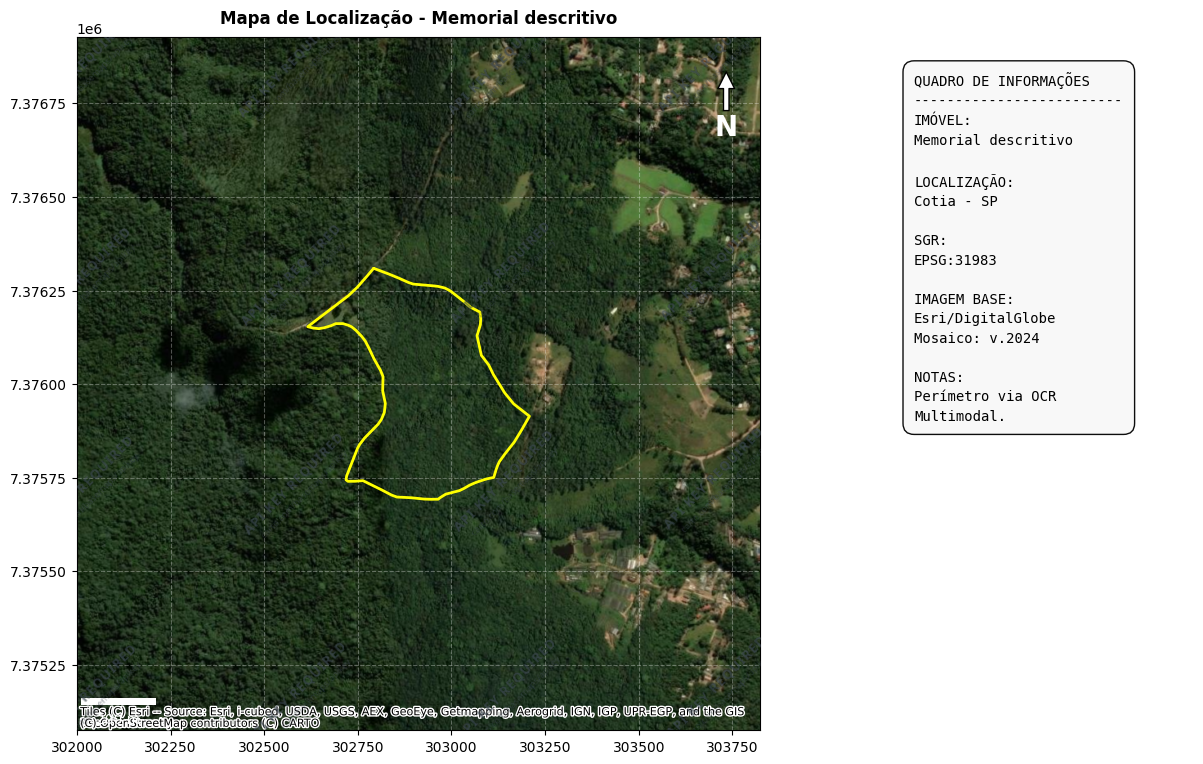

In [ ]:
gerar_mapa_profissional(coords, "EPSG:31983", "Memorial descritivo", margem = 1)
